In [ ]:
!pip install xgboost transformers sentence-transformers --quiet


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 4.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 17.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 59.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 48.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 1.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 5.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 16.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 7.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 5.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 43.2 MB/s eta 0:00:00


In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error, r2_score
from sentence_transformers import SentenceTransformer
import matplotlib.pyplot as plt
import seaborn as sns

# from google.generativeai import GenerativeModel
# gemini_model = GenerativeModel("models/gemini-1.5-pro")
# def explain_score_with_gemini(features):
#     prompt = f"Given the following startup traction and moat data: {features}, provide an analysis of the company's competitive position."
#     return gemini_model.generate_content(prompt).text

sbert_model = SentenceTransformer('all-MiniLM-L6-v2')

/usr/local/lib/python3.11/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

tokenizer_config.json:   0%|          | 0.00/350 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

In [ ]:
def load_traction_moat_data(dummy=True, path=None):
    if dummy:
        np.random.seed(42)
        n = 500
        # Simulated traction features
        monthly_active_users = np.random.randint(1000, 100000, size=n)
        mrr_growth_rate = np.random.uniform(0.01, 0.25, size=n)
        waitlist_growth = np.random.randint(100, 5000, size=n)
        feature_adoption_score = np.random.uniform(0, 1, size=n)
        churn_rate = np.random.uniform(0.01, 0.30, size=n)
        retention_score = np.random.uniform(0, 1, size=n)
        avg_session_duration = np.random.uniform(2, 30, size=n)

        # Optional moat-related text fields
        user_testimonials = np.random.choice([
            "Great product, can't live without it.",
            "Nice but too expensive.",
            "Buggy and unstable.",
            "Amazing support and features!"
        ], size=n)

        product_description = np.random.choice([
            "Proprietary AI model with large dataset access.",
            "Open source stack with limited defensibility.",
            "High switching costs due to deep CRM integration.",
            "Simple tool, easily replicable."
        ], size=n)

        df = pd.DataFrame({
            'monthly_active_users': monthly_active_users,
            'mrr_growth_rate': mrr_growth_rate,
            'waitlist_growth': waitlist_growth,
            'feature_adoption_score': feature_adoption_score,
            'churn_rate': churn_rate,
            'retention_score': retention_score,
            'avg_session_duration': avg_session_duration,
            'user_testimonials': user_testimonials,
            'product_description': product_description
        })

        # Synthetic traction score
        df['traction_score'] = (
            df['mrr_growth_rate'] * 40 +
            df['feature_adoption_score'] * 20 +
            df['retention_score'] * 20 -
            df['churn_rate'] * 15 +
            (df['monthly_active_users'] / 100000) * 5
        ).clip(0, 100)

        return df
    else:
        return pd.read_csv(path)


In [ ]:
def preprocess_traction(df):
    features = [
        'monthly_active_users', 'mrr_growth_rate', 'waitlist_growth',
        'feature_adoption_score', 'churn_rate', 'retention_score', 'avg_session_duration'
    ]
    X = df[features]
    y = df['traction_score']

    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)

    return train_test_split(X_scaled, y, test_size=0.2, random_state=42)


In [ ]:
def train_traction_model(X_train, y_train):
    model = XGBRegressor(n_estimators=100, learning_rate=0.1, max_depth=5)
    model.fit(X_train, y_train)
    return model


In [ ]:
def evaluate_traction_model(model, X_test, y_test):
    preds = model.predict(X_test)
    mae = mean_absolute_error(y_test, preds)
    r2 = r2_score(y_test, preds)
    print(f"📉 MAE: {mae:.2f}")
    print(f"📊 R² Score: {r2:.2f}")

    plt.figure(figsize=(8, 5))
    sns.scatterplot(x=y_test, y=preds)
    plt.xlabel("Actual")
    plt.ylabel("Predicted")
    plt.title("Actual vs Predicted Traction Score")
    plt.grid(True)
    plt.show()


In [ ]:
def embed_moat_texts(df):
    df['moat_embedding'] = df['product_description'].apply(lambda x: sbert_model.encode(x))
    return df

In [ ]:
def run_full_pipeline():
    df = load_traction_moat_data()
    print(f"✅ Dataset shape: {df.shape}")
    display(df.head())

    X_train, X_test, y_train, y_test = preprocess_traction(df)
    model = train_traction_model(X_train, y_train)
    evaluate_traction_model(model, X_test, y_test)

    df = embed_moat_texts(df)
    print("\n📦 Sample moat embedding vector for first row:")
    print(df['moat_embedding'].iloc[0][:10])

✅ Dataset shape: (500, 10)


,monthly_active_users,mrr_growth_rate,waitlist_growth,feature_adoption_score,churn_rate,retention_score,avg_session_duration,user_testimonials,product_description,traction_score
0,16795,0.052079,4480,0.776597,0.222748,0.034670,8.310676,Nice but too expensive.,"Simple tool, easily replicable.",15.807040
1,1860,0.014119,4258,0.770922,0.233098,0.582807,7.483326,"Great product, can't live without it.","Simple tool, easily replicable.",24.235844
2,77820,0.193207,4857,0.844783,0.013199,0.995438,5.942483,Buggy and unstable.,"Simple tool, easily replicable.",48.225727
3,55886,0.203659,2813,0.761024,0.130685,0.855696,19.427582,Buggy and unstable.,High switching costs due to deep CRM integration.,41.314796
4,7265,0.093113,2303,0.626220,0.149590,0.521446,23.877012,Nice but too expensive.,"Simple tool, easily replicable.",24.797245


📉 MAE: 1.24
📊 R² Score: 0.97


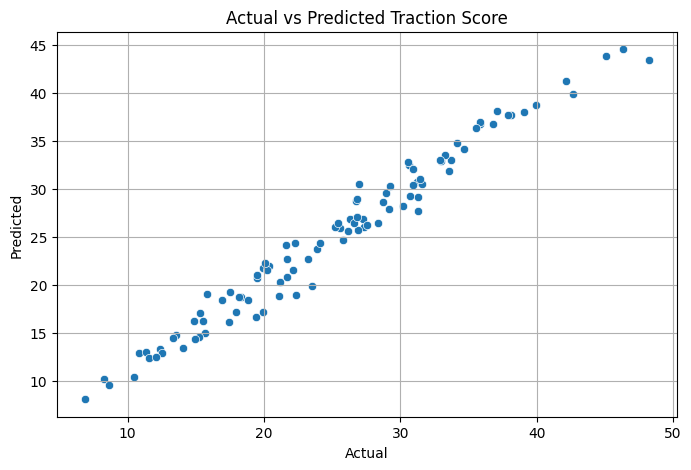


📦 Sample moat embedding vector for first row:
[-0.15530229  0.01890425 -0.0429878  -0.02416377 -0.04198926 -0.1042435
 -0.04377434 -0.03454216 -0.01329404  0.04453404]


In [ ]:
run_full_pipeline()
